# Notebook 3 — Gráficas de abundancias taxonómicas

Genera barras apiladas de abundancia relativa por niveles taxonómicos y guarda las figuras en `plots/`.

In [1]:
# Instalación de dependencias (ejecutar si es necesario)
# En Google Colab o un ambiente limpio, descomenta la siguiente línea:
!pip install pandas numpy scipy scikit-bio seaborn matplotlib statsmodels openpyxl xlrd scikit-learn

import os
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook")

PLOTS_DIR = Path("plots")
PLOTS_DIR.mkdir(exist_ok=True)

ALL_SAMPLES_URL = "https://raw.githubusercontent.com/shadayguerrero/neonatal-gut-microbiome-analysis/refs/heads/main/data/all_samples.tsv"
METADATA_URL = "https://raw.githubusercontent.com/shadayguerrero/neonatal-gut-microbiome-analysis/refs/heads/main/data/metadata_cibimi.csv"
FUNCTION_URL = "https://raw.githubusercontent.com/shadayguerrero/neonatal-gut-microbiome-analysis/refs/heads/main/data/output_all_levels_and_function.csv"

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

def save_current_fig(filename, dpi=300):
    """Guarda la figura actual dentro de plots/ y la muestra."""
    path = PLOTS_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Figura guardada en: {path}")
    plt.show()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 44.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 46.5 MB/s eta 0:00:00


## 1. Carga y preparación de datos

,Your Sample ID,Baby number,Sampling Date,Weeks of gestation,Sample Type,Group,Sex,Weight,Size,Head Circunference,Abdominal Circunference,Necrotizing enterocolitis,Type of Birth,Clasification birth weight,Week
SampleID,,,,,,,,,,,,,,,
S00SO-0001,C3.1,3,Week 1 (Birth),27.0,human feces,CONTROL,fem,800.0,34.0,24.0,18.0,No presence,Cesarean,Extremely low,1
S00SO-0002,C3.2,3,Week 2,NaN,human feces,CONTROL,fem,805.0,34.0,23.0,18.0,No presence,Cesarean,Extremely low,2
S00SO-0003,C3.3,3,Week 3,NaN,human feces,CONTROL,fem,870.0,34.0,24.0,20.0,No presence,Cesarean,Extremely low,3
S00SO-0004,C3.4,3,Week 4,NaN,human feces,CONTROL,fem,910.0,34.0,24.0,20.0,No presence,Cesarean,Extremely low,4
S00SO-0005,C3.5,3,Week 5,NaN,human feces,CONTROL,fem,NaN,NaN,NaN,NaN,No presence,Cesarean,Extremely low,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
S00SO-0082,P37.4,37,Week 4,NaN,human feces,PROBIOTIC,masc,1245.0,40.0,25.0,21.0,No presence,Parturition,NaN,4
S00SO-0083,P38.1,38,Week 1 (Birth),30.0,human feces,PROBIOTIC,masc,1380.0,41.0,29.0,22.0,No presence,Cesarean,Very low,1
S00SO-0084,P38.2,38,Week 2,NaN,human feces,PROBIOTIC,masc,1280.0,41.0,29.0,22.0,No presence,Cesarean,NaN,2


In [2]:
metadata = pd.read_csv(METADATA_URL).rename(columns={"MBI Sample ID": "SampleID"})
metadata["SampleID"] = metadata["SampleID"].astype(str).str.strip()
metadata = metadata.set_index("SampleID")

otu = pd.read_csv(ALL_SAMPLES_URL, sep="\t", skiprows=1).rename(columns={"#OTU ID": "OTU_ID"})
if "OTU_ID" not in otu.columns:
    otu = pd.read_csv(ALL_SAMPLES_URL, sep="\t").rename(columns={"#OTU ID": "OTU_ID"})
otu = otu.set_index("OTU_ID")

taxonomy_df = otu["Consensus Lineage"].str.split(";", expand=True)
taxonomy_df.columns = [f"taxonomy_{i}" for i in range(taxonomy_df.shape[1])]
for col in taxonomy_df.columns:
    taxonomy_df[col] = (
        taxonomy_df[col]
        .fillna("Unclassified")
        .astype(str)
        .str.replace(r"^[a-z]__", "", regex=True)
        .str.strip()
        .replace({"": "Unclassified", "nan": "Unclassified"})
    )

count_df = otu.drop(columns=["Consensus Lineage"]).apply(pd.to_numeric, errors="coerce").fillna(0)
# Quitar columnas técnicas si aparecen en el archivo.
sample_cols = [c for c in count_df.columns if not (str(c).startswith("DNA") or str(c).startswith("S001Z"))]
count_df = count_df[sample_cols]

df_combined = pd.concat([taxonomy_df, count_df], axis=1)
print(f"ASVs/features: {df_combined.shape[0]}")
print(f"Muestras: {len(sample_cols)}")
df_combined.head()

ASVs/features: 10794
Muestras: 83


,taxonomy_0,taxonomy_1,taxonomy_2,taxonomy_3,taxonomy_4,taxonomy_5,taxonomy_6,S00SO-0001_S1931_R-taxa,S00SO-0002_S1941_R-taxa,S00SO-0003_S1951_R-taxa,...,S00SO-0076_S2681_R-taxa,S00SO-0077_S2691_R-taxa,S00SO-0078_S2701_R-taxa,S00SO-0079_S2711_R-taxa,S00SO-0080_S2721_R-taxa,S00SO-0081_S2731_R-taxa,S00SO-0082_S2741_R-taxa,S00SO-0083_S2751_R-taxa,S00SO-0084_S2761_R-taxa,S00SO-0086_S2781_R-taxa
OTU_ID,,,,,,,,,,,,,,,,,,,,,
2,Bacteria,p__,c__,o__,f__,g__,s__,34.0,2205.0,6970.0,...,41.0,873.0,12935.0,75.0,51.0,7767.0,10469.0,47.0,247.0,4735.0
976,Bacteria,p__Bacteroidota,c__,o__,f__,g__,s__,4.0,8.0,6.0,...,19.0,43.0,17.0,32.0,22.0,15.0,27.0,17.0,9.0,44.0
171549,Bacteria,p__Bacteroidota,c__Bacteroidia,o__Bacteroidales,f__,g__,s__,75.0,81.0,78.0,...,159.0,312.0,181.0,292.0,193.0,111.0,155.0,169.0,86.0,269.0
815,Bacteria,p__Bacteroidota,c__Bacteroidia,o__Bacteroidales,f__Bacteroidaceae,g__,s__,25.0,30.0,25.0,...,36.0,102.0,52.0,95.0,50.0,32.0,49.0,38.0,19.0,100.0
816,Bacteria,p__Bacteroidota,c__Bacteroidia,o__Bacteroidales,f__Bacteroidaceae,g__Bacteroides,s__,133.0,121.0,151.0,...,176.0,280.0,226.0,400.0,304.0,166.0,215.0,211.0,160.0,284.0


## 2. Funciones para abundancia relativa

In [10]:
TAX_LEVELS = {
    "kingdom": 0, "phylum": 1, "class": 2, "order": 3,
    "family": 4, "genus": 5, "species": 6
}

def aggregate_by_taxonomy(df, level="phylum"):
    level = level.lower()
    if level not in TAX_LEVELS:
        raise ValueError(f"Nivel no reconocido. Usa: {list(TAX_LEVELS)}")
    tax_col = f"taxonomy_{TAX_LEVELS[level]}"
    if tax_col not in df.columns:
        available = [c for c in df.columns if c.startswith("taxonomy_")]
        tax_col = available[-1]
        print(f"Nivel solicitado no disponible. Usando {tax_col}.")
    sample_columns = [c for c in df.columns if not c.startswith("taxonomy_")]
    abundance = df.groupby(tax_col)[sample_columns].sum()
    return abundance

def relative_abundance_top(abundance, top_n=12):
    rel = abundance.div(abundance.sum(axis=0).replace(0, np.nan), axis=1).fillna(0)
    top_taxa = rel.mean(axis=1).sort_values(ascending=False).head(top_n).index
    rel_top = rel.loc[top_taxa].copy()
    other = rel.drop(index=top_taxa).sum(axis=0)
    if (other > 0).any():
        rel_top.loc["Otros"] = other

    result_df = rel_top.T
    # Clean the column names by removing taxonomic prefixes (e.g., 'p__', 'g__')
    result_df.columns = result_df.columns.str.replace(r"^[kpcofgs]__", "", regex=True)
    return result_df

def clean_sample_id(sample_name):
    return str(sample_name).split("_")[0].strip()

def add_metadata_to_relative(rel_samples):
    rel = rel_samples.copy()
    rel.index = [clean_sample_id(i) for i in rel.index]
    rel = rel.groupby(rel.index).sum()
    return rel.join(metadata, how="left")

## 3. Barras apiladas por muestra

Figura guardada en: plots/abundancia_relativa_phylum_por_muestra_ordenada_por_group.png


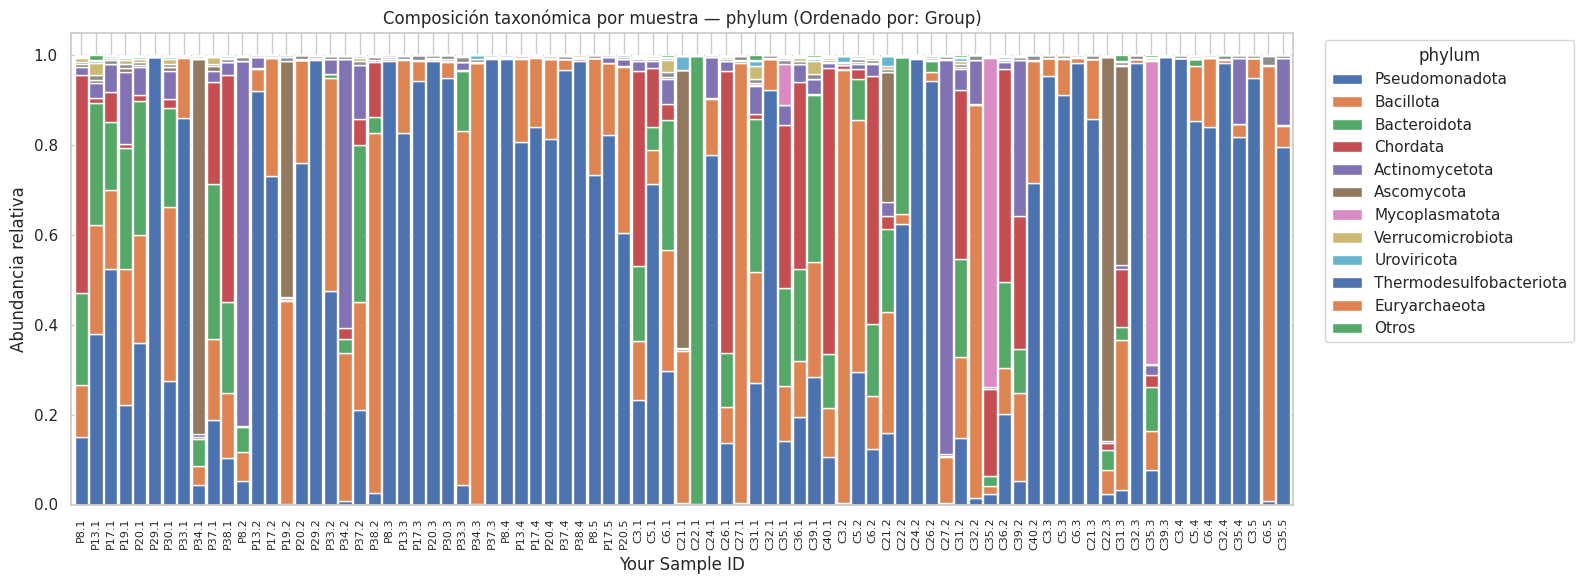

Figura guardada en: plots/abundancia_relativa_genus_por_muestra_ordenada_por_group.png


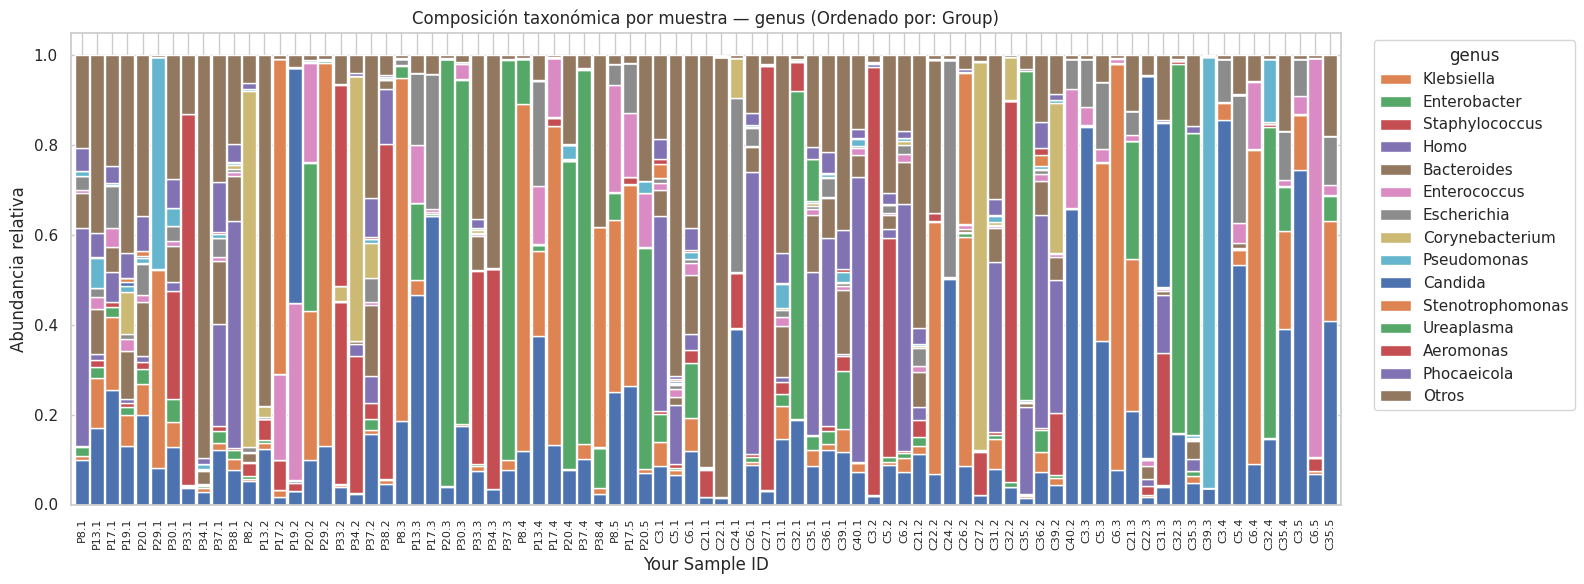

Figura guardada en: plots/abundancia_relativa_phylum_por_muestra_ordenada_por_week.png


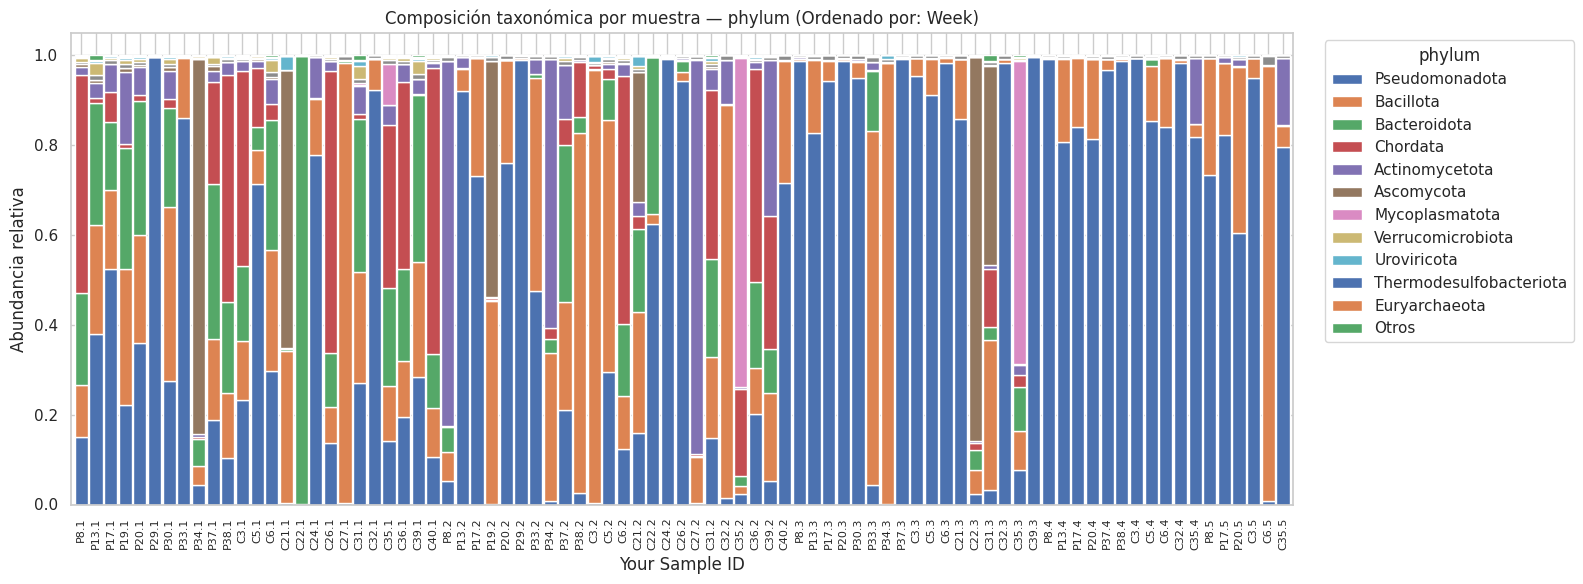

Figura guardada en: plots/abundancia_relativa_genus_por_muestra_ordenada_por_week.png


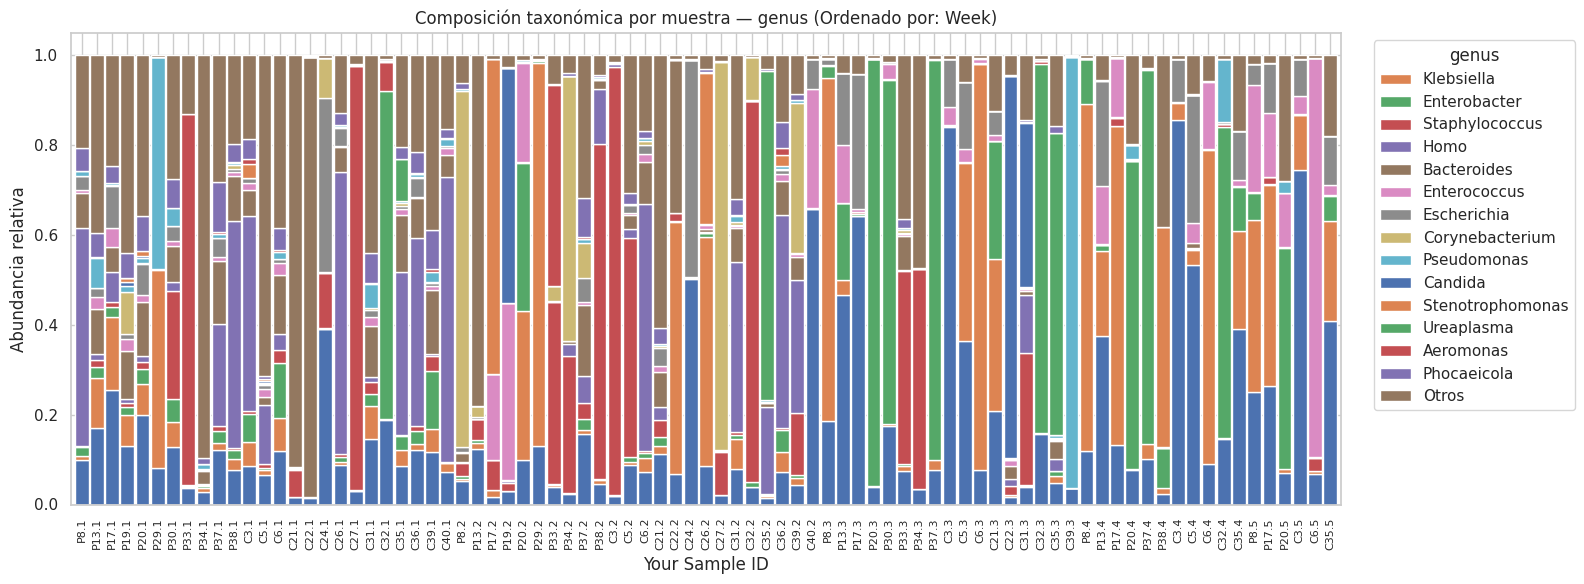

In [19]:
def plot_stacked_by_sample(level="phylum", top_n=12, sort_by="Group", df_input=None):
    if df_input is None:
        df_input = df_combined
    abundance = aggregate_by_taxonomy(df_input, level)
    rel = relative_abundance_top(abundance, top_n=top_n)
    rel_meta = add_metadata_to_relative(rel)
    taxa_cols = [c for c in rel_meta.columns if c in rel.columns]

    # Define custom order for 'Group' column
    group_order = ['PROBIOTIC', 'CONTROL']
    if 'Group' in rel_meta.columns:
        rel_meta['Group'] = pd.Categorical(rel_meta['Group'], categories=group_order, ordered=True)

    # Dynamically construct sorting columns based on 'sort_by' parameter
    if sort_by == "Group":
        order_cols = ["Group", "Week", "Baby number"]
    elif sort_by == "Week":
        order_cols = ["Week", "Group", "Baby number"]
    else:
        order_cols = ["Group", "Week", "Baby number"] # Fallback to default sorting

    sort_cols = [c for c in order_cols if c in rel_meta.columns]
    if sort_cols:
        rel_meta = rel_meta.sort_values(sort_cols)

    plot_df = rel_meta[taxa_cols]
    ax = plot_df.plot(kind="bar", stacked=True, figsize=(16, 6), width=0.9)
    ax.set_ylabel("Abundancia relativa")
    ax.set_xlabel("Your Sample ID")
    ax.set_title(f"Composición taxonómica por muestra — {level} (Ordenado por: {sort_by})") # Added sort_by to title
    ax.legend(title=level, bbox_to_anchor=(1.02, 1), loc="upper left")
    ax.set_xticklabels(rel_meta["Your Sample ID"])
    ax.tick_params(axis='x', rotation=90, labelsize=8)
    # Modified filename to include sorting method
    save_current_fig(f"abundancia_relativa_{level}_por_muestra_ordenada_por_{sort_by.lower()}.png")
    return rel_meta

# Generate plots sorted by 'Group' (explicitly setting sort_by)
rel_phylum_group_sorted = plot_stacked_by_sample("phylum", top_n=12, sort_by="Group")
rel_genus_group_sorted = plot_stacked_by_sample("genus", top_n=15, sort_by="Group")

# Generate new plots sorted by 'Week'
rel_phylum_week_sorted = plot_stacked_by_sample("phylum", top_n=12, sort_by="Week")
rel_genus_week_sorted = plot_stacked_by_sample("genus", top_n=15, sort_by="Week")

## 4. Promedio por grupo

Figura guardada en: plots/abundancia_relativa_phylum_promedio_por_Group.png


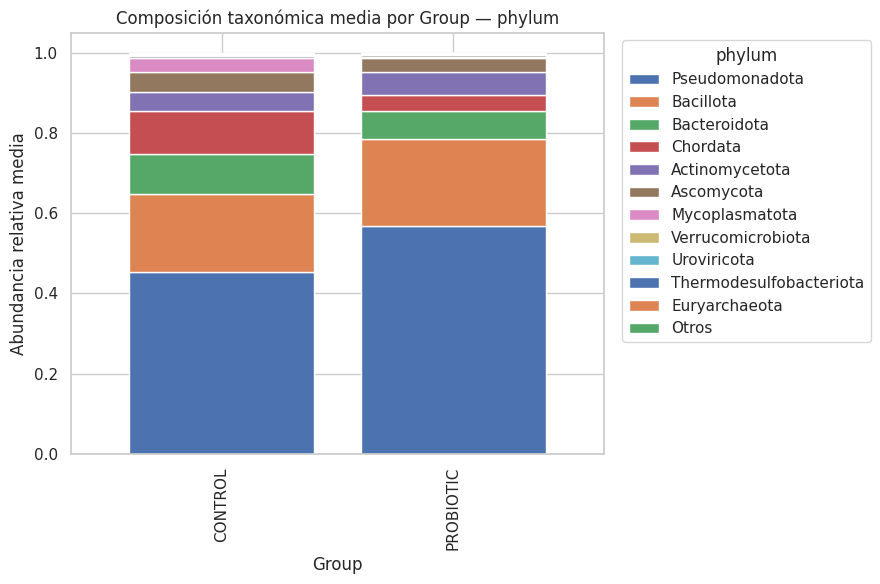

Figura guardada en: plots/abundancia_relativa_genus_promedio_por_Group.png


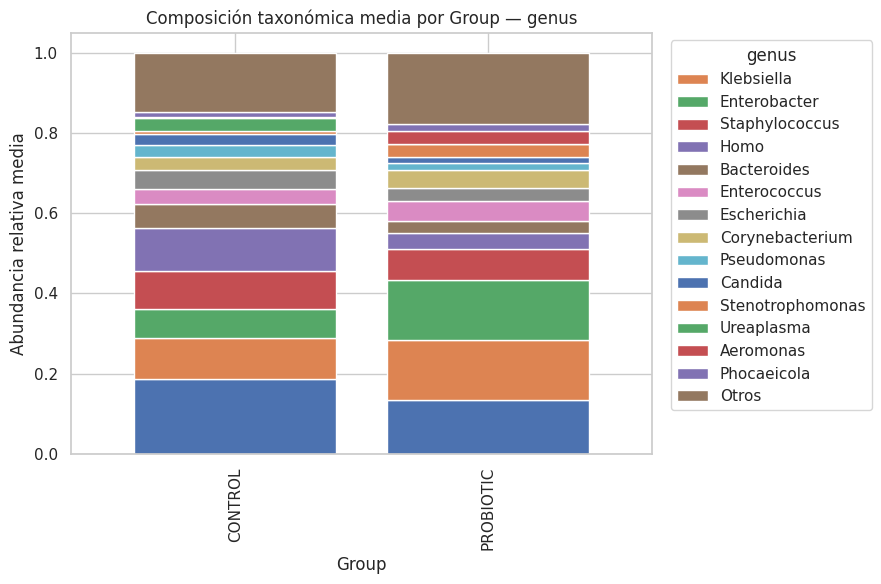

In [20]:
def plot_mean_by_group(level="phylum", top_n=12, group_col="Group", df_input=None):
    if df_input is None:
        df_input = df_combined
    abundance = aggregate_by_taxonomy(df_input, level)
    rel = relative_abundance_top(abundance, top_n=top_n)
    rel_meta = add_metadata_to_relative(rel)
    taxa_cols = [c for c in rel.columns if c in rel_meta.columns]
    if group_col not in rel_meta.columns:
        print(f"No se encontró {group_col}.")
        return None
    mean_rel = rel_meta.groupby(group_col)[taxa_cols].mean()
    ax = mean_rel.plot(kind="bar", stacked=True, figsize=(9, 6), width=0.8)
    ax.set_ylabel("Abundancia relativa media")
    ax.set_xlabel(group_col)
    ax.set_title(f"Composición taxonómica media por {group_col} — {level}")
    ax.legend(title=level, bbox_to_anchor=(1.02, 1), loc="upper left")
    save_current_fig(f"abundancia_relativa_{level}_promedio_por_{group_col}.png")
    mean_rel.to_csv(f"abundancia_relativa_{level}_promedio_por_{group_col}.csv")
    return mean_rel

mean_phylum_group = plot_mean_by_group("phylum", top_n=12, group_col="Group")
mean_genus_group = plot_mean_by_group("genus", top_n=15, group_col="Group")

## 6. Gráficos solo para el Reino Bacteria

ASVs/features (Bacteria): 9785
Generando gráficos de barras apiladas para bacterias (ordenados por Grupo)...
Figura guardada en: plots/abundancia_relativa_phylum_por_muestra_ordenada_por_group.png


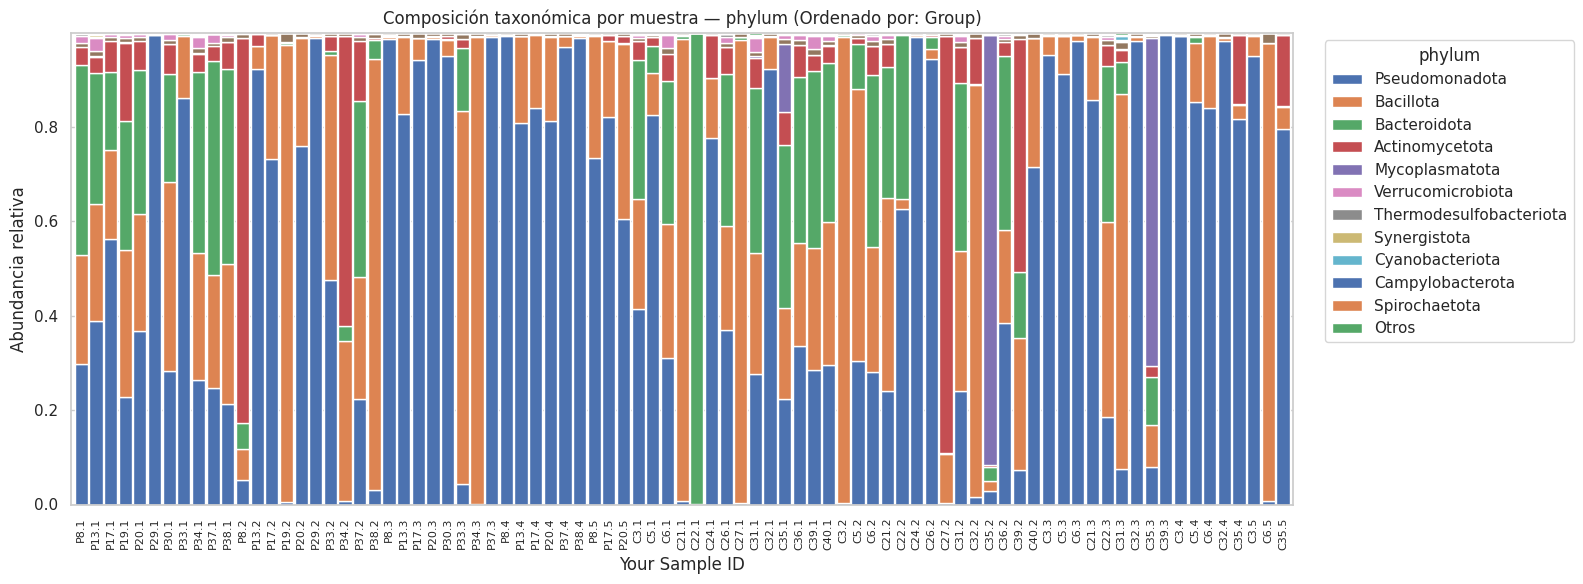

Figura guardada en: plots/abundancia_relativa_genus_por_muestra_ordenada_por_group.png


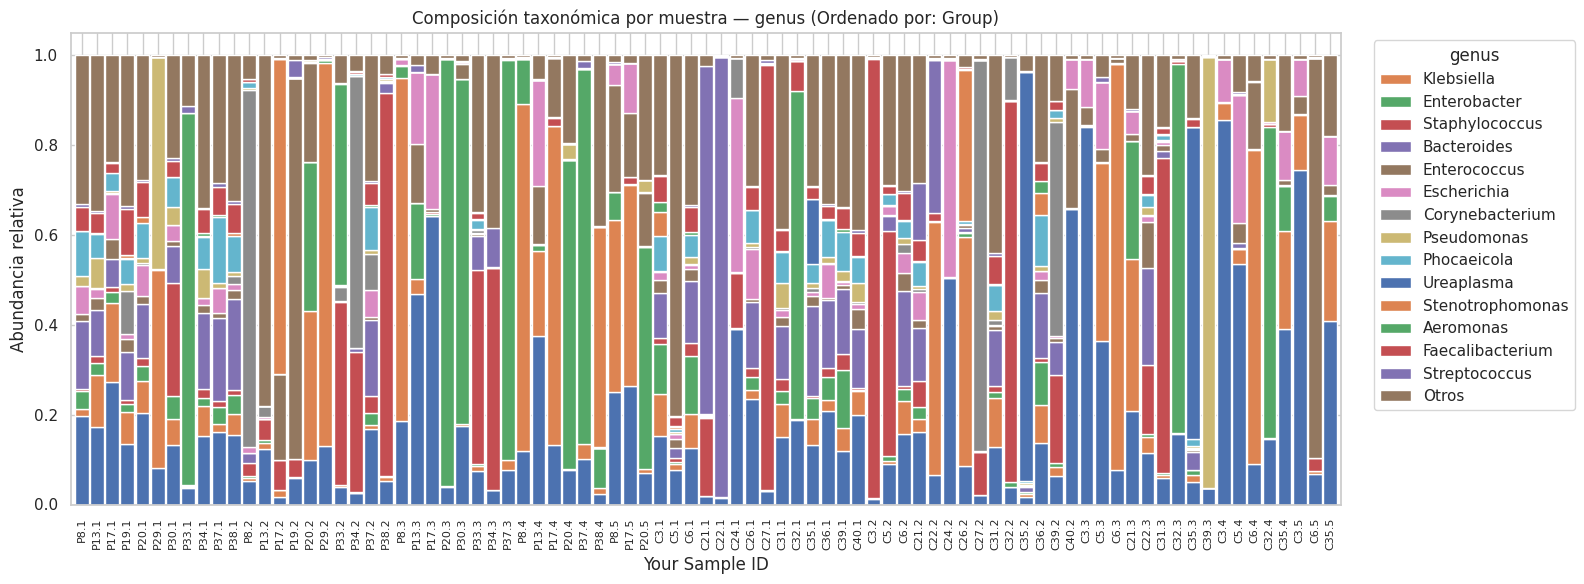

Generando gráficos de barras apiladas para bacterias (ordenados por Semana)...
Figura guardada en: plots/abundancia_relativa_phylum_por_muestra_ordenada_por_week.png


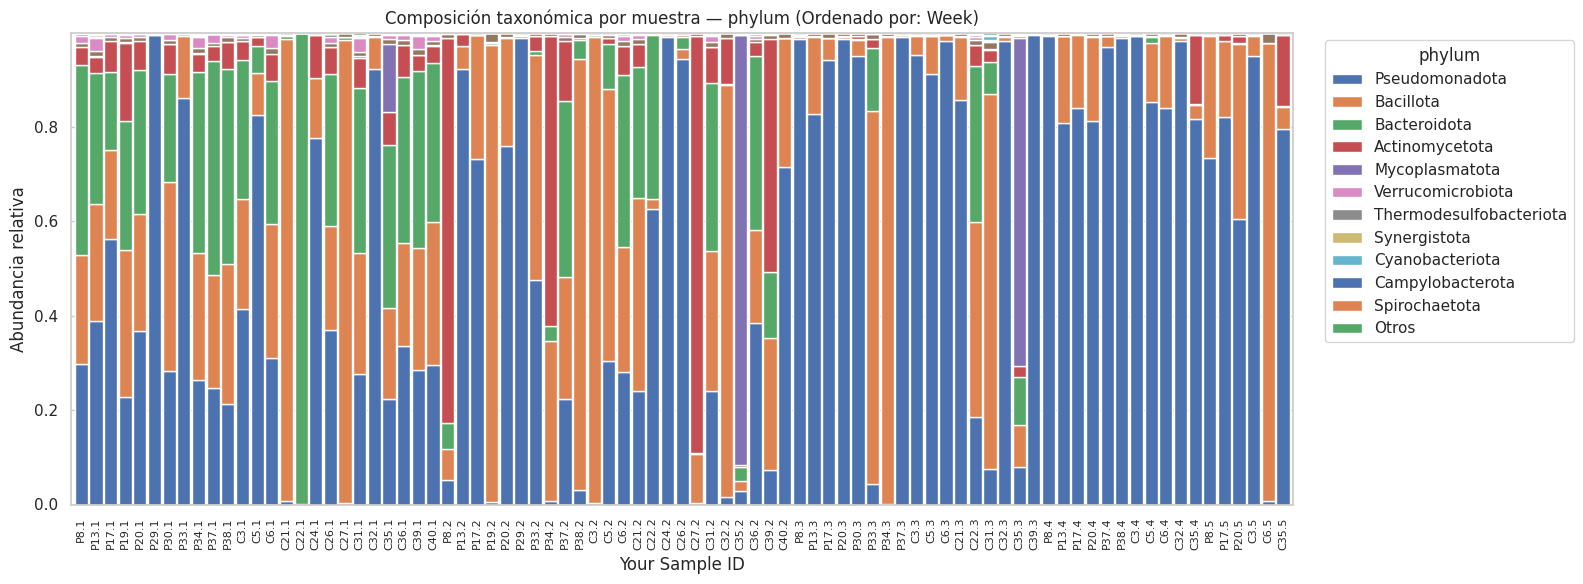

Figura guardada en: plots/abundancia_relativa_genus_por_muestra_ordenada_por_week.png


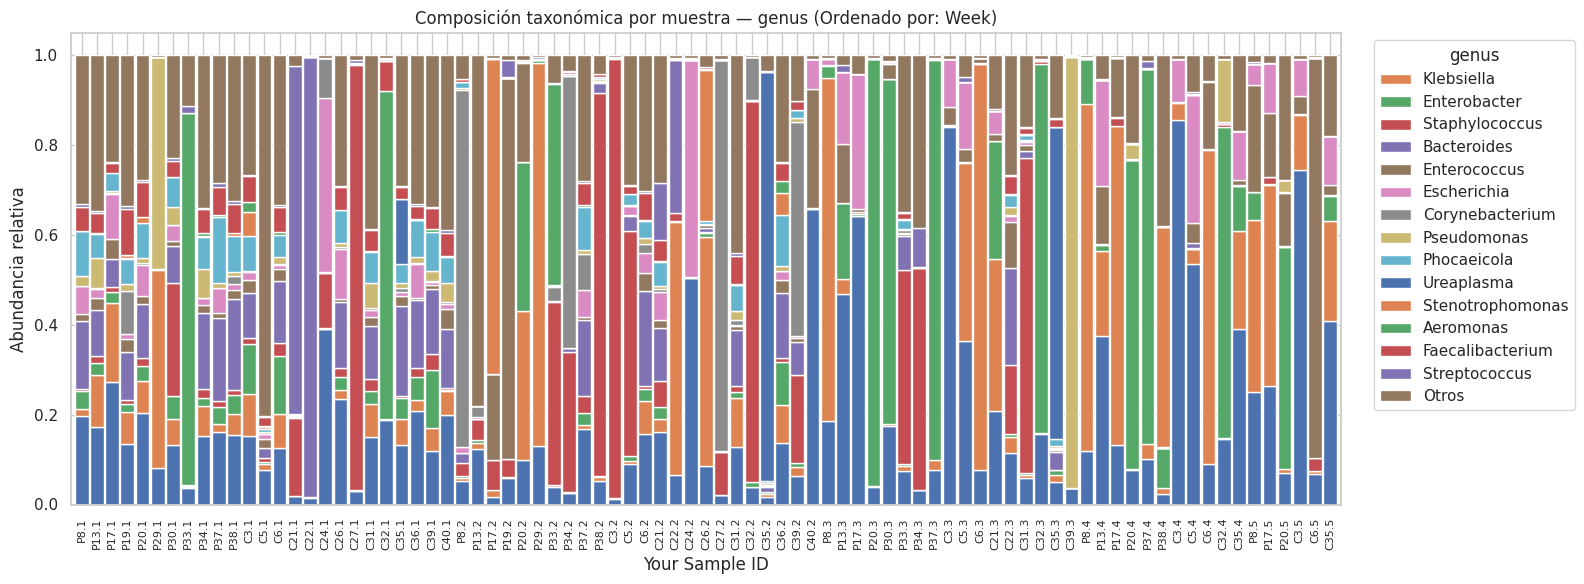

Generando gráficos de promedio por grupo para bacterias...
Figura guardada en: plots/abundancia_relativa_phylum_promedio_por_Group.png


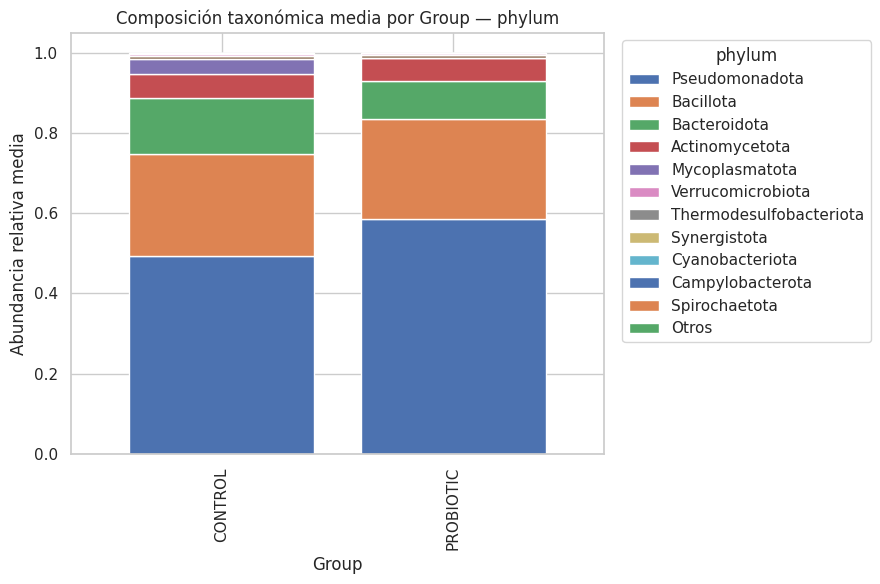

Figura guardada en: plots/abundancia_relativa_genus_promedio_por_Group.png


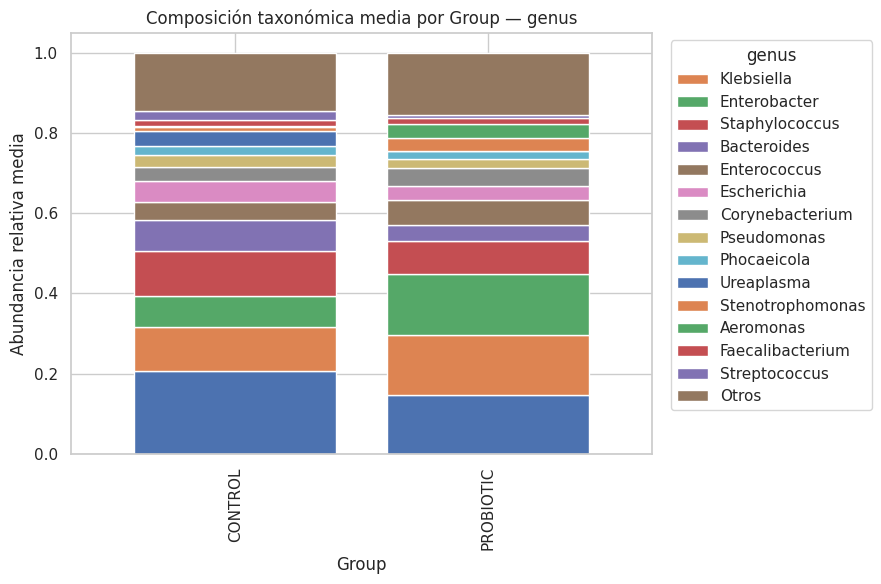

Generando heatmap para bacterias...
Figura guardada en: plots/heatmap_top_25_genus_bacteria.png


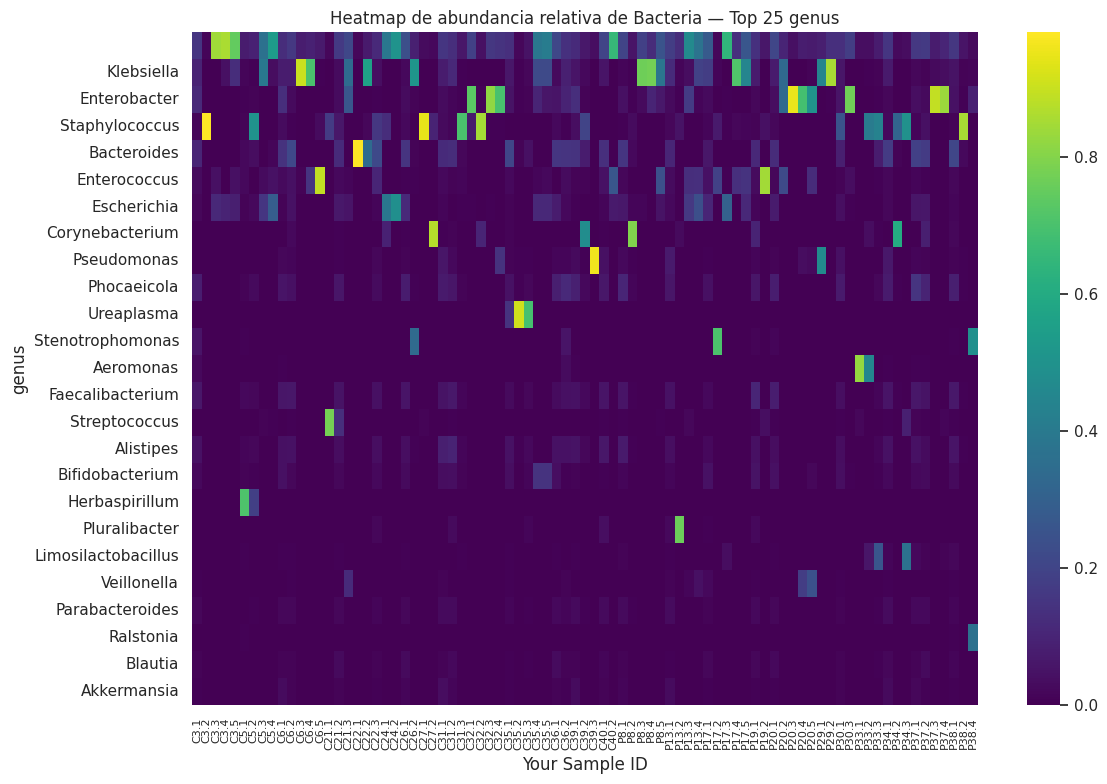

In [21]:
# Filtrar el DataFrame para incluir solo el reino Bacteria
df_bacteria = df_combined[df_combined['taxonomy_0'] == 'Bacteria'].copy()

print(f"ASVs/features (Bacteria): {df_bacteria.shape[0]}")

# Generar gráficos de barras apiladas solo para bacterias, ordenados por 'Group'
print("Generando gráficos de barras apiladas para bacterias (ordenados por Grupo)...")
rel_phylum_bacteria_group_sorted = plot_stacked_by_sample("phylum", top_n=12, sort_by="Group", df_input=df_bacteria)
rel_genus_bacteria_group_sorted = plot_stacked_by_sample("genus", top_n=15, sort_by="Group", df_input=df_bacteria)

# Generar gráficos de barras apiladas solo para bacterias, ordenados por 'Week'
print("Generando gráficos de barras apiladas para bacterias (ordenados por Semana)...")
rel_phylum_bacteria_week_sorted = plot_stacked_by_sample("phylum", top_n=12, sort_by="Week", df_input=df_bacteria)
rel_genus_bacteria_week_sorted = plot_stacked_by_sample("genus", top_n=15, sort_by="Week", df_input=df_bacteria)

# Generar gráficos de promedio por grupo solo para bacterias
print("Generando gráficos de promedio por grupo para bacterias...")
mean_phylum_bacteria_group = plot_mean_by_group("phylum", top_n=12, group_col="Group", df_input=df_bacteria)
mean_genus_bacteria_group = plot_mean_by_group("genus", top_n=15, group_col="Group", df_input=df_bacteria)

# Generar heatmap para bacterias
def plot_taxa_heatmap_bacteria(level="genus", top_n=25):
    abundance = aggregate_by_taxonomy(df_bacteria, level)
    rel = relative_abundance_top(abundance, top_n=top_n).drop(columns=["Otros"], errors="ignore")
    rel.index = [clean_sample_id(i) for i in rel.index]
    rel = rel.groupby(rel.index).sum()

    # Join with metadata to get 'Your Sample ID' for labels
    rel_with_meta = rel.join(metadata, how="left")

    plt.figure(figsize=(12, 8))
    sns.heatmap(rel.T, cmap="viridis", xticklabels=rel_with_meta["Your Sample ID"].values)
    plt.title(f"Heatmap de abundancia relativa de Bacteria — Top {top_n} {level}")
    plt.xlabel("Your Sample ID")
    plt.ylabel(level)
    plt.xticks(rotation=90, fontsize=8)
    save_current_fig(f"heatmap_top_{top_n}_{level}_bacteria.png")
    return rel_with_meta

print("Generando heatmap para bacterias...")
heatmap_genus_bacteria = plot_taxa_heatmap_bacteria("genus", top_n=25)

## 5. Heatmap de taxones principales

In [16]:
def plot_taxa_heatmap(level="genus", top_n=25):
    abundance = aggregate_by_taxonomy(df_combined, level)
    rel = relative_abundance_top(abundance, top_n=top_n).drop(columns=["Otros"], errors="ignore")
    rel.index = [clean_sample_id(i) for i in rel.index]
    rel = rel.groupby(rel.index).sum()

    # Join with metadata to get 'Your Sample ID' for labels
    rel_with_meta = rel.join(metadata, how="left")

    plt.figure(figsize=(12, 8))
    sns.heatmap(rel.T, cmap="viridis", xticklabels=rel_with_meta["Your Sample ID"].values)
    plt.title(f"Heatmap de abundancia relativa — Top {top_n} {level}")
    plt.xlabel("Your Sample ID") # Changed label to Your Sample ID
    plt.ylabel(level)
    plt.xticks(rotation=90, fontsize=8) # Rotate for better readability
    save_current_fig(f"heatmap_top_{top_n}_{level}.png")
    return rel_with_meta # Return the DataFrame with metadata for consistency

In [ ]:
/content/plots